# Task 06 - Client Segmentation Using Clustering

Name: Malaika Noor

Objective:
Group CoreTech clients based on similar characteristics using K-Means Clustering and Hierarchical Clustering.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## Creating Sample Client Dataset

In [13]:
data = {
    "Client_ID":[1,2,3,4,5,6,7,8,9,10],
    "Projects":[2,5,3,8,10,12,4,6,9,11],
    "Spending":[5000,12000,7000,20000,25000,30000,9000,15000,22000,28000],
    "Team_Size":[2,4,3,8,10,12,4,5,9,11],
    "Support_Tickets":[10,8,9,5,4,3,7,6,4,2]
}

df = pd.DataFrame(data)

print(df)

   Client_ID  Projects  Spending  Team_Size  Support_Tickets
0          1         2      5000          2               10
1          2         5     12000          4                8
2          3         3      7000          3                9
3          4         8     20000          8                5
4          5        10     25000         10                4
5          6        12     30000         12                3
6          7         4      9000          4                7
7          8         6     15000          5                6
8          9         9     22000          9                4
9         10        11     28000         11                2


## Selecting Features

In [14]:
X = df[["Projects","Spending","Team_Size","Support_Tickets"]]

print(X.head())

   Projects  Spending  Team_Size  Support_Tickets
0         2      5000          2               10
1         5     12000          4                8
2         3      7000          3                9
3         8     20000          8                5
4        10     25000         10                4


## Scaling Data

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.50755672 -1.4454592  -1.39970842  1.66540833]
 [-0.60302269 -0.62284014 -0.81649658  0.87235674]
 [-1.20604538 -1.21042518 -1.1081025   1.26888254]
 [ 0.30151134  0.31729592  0.34992711 -0.31722063]
 [ 0.90453403  0.90488096  0.93313895 -0.71374643]
 [ 1.50755672  1.492466    1.51635079 -1.11027222]
 [-0.90453403 -0.97539117 -0.81649658  0.47583095]
 [-0.30151134 -0.27028912 -0.52489066  0.07930516]
 [ 0.60302269  0.55232994  0.64153303 -0.71374643]
 [ 1.20604538  1.25743199  1.22474487 -1.50679801]]


## Elbow Method

In [17]:
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

print(wcss)

[40.0, 7.312540364992129, 4.479324356356807, 1.821611990293365, 1.2062716176760901, 0.7247514724746427, 0.5305430736092686, 0.33633467474389434, 0.15011766467267879, 0.0]


## Elbow Method Visualization

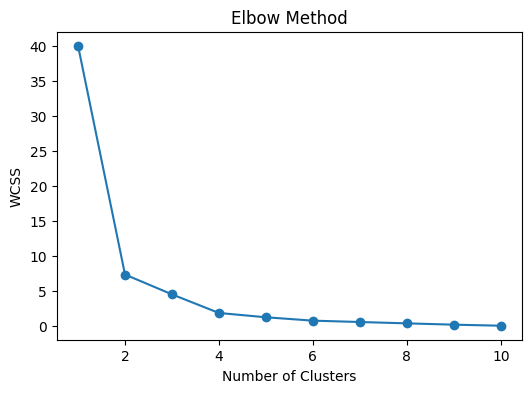

In [18]:
plt.figure(figsize=(6,4))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## Applying K-Means Clustering

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print(df)

   Client_ID  Projects  Spending  Team_Size  Support_Tickets  KMeans_Cluster
0          1         2      5000          2               10               1
1          2         5     12000          4                8               1
2          3         3      7000          3                9               1
3          4         8     20000          8                5               0
4          5        10     25000         10                4               2
5          6        12     30000         12                3               2
6          7         4      9000          4                7               1
7          8         6     15000          5                6               0
8          9         9     22000          9                4               2
9         10        11     28000         11                2               2


## K-Means Cluster Visualization

In [8]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Spending"],
    df["Projects"],
    c=df["KMeans_Cluster"]
)

plt.xlabel("Client Spending")
plt.ylabel("Projects")
plt.title("K-Means Clusters")

plt.show()

Accuracy: 0.5
[[1 1]
 [0 0]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Hierarchical Clustering

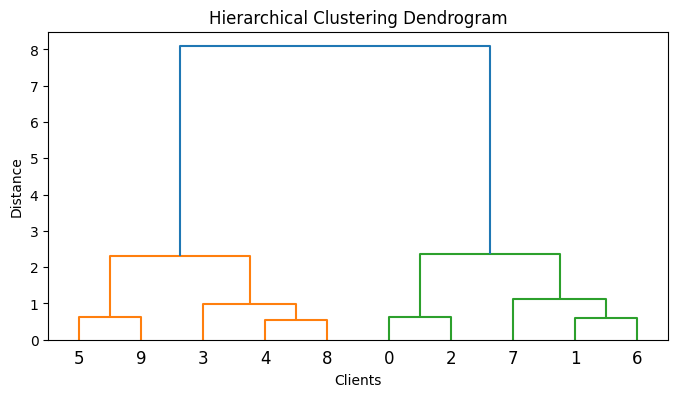

In [20]:
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(8,4))

dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clients")
plt.ylabel("Distance")

plt.show()

## Creating Hierarchical Clusters

In [21]:
df["Hierarchical_Cluster"] = fcluster(
    linkage_matrix,
    3,
    criterion="maxclust"
)

print(df)

   Client_ID  Projects  Spending  Team_Size  Support_Tickets  KMeans_Cluster  \
0          1         2      5000          2               10               1   
1          2         5     12000          4                8               1   
2          3         3      7000          3                9               1   
3          4         8     20000          8                5               0   
4          5        10     25000         10                4               2   
5          6        12     30000         12                3               2   
6          7         4      9000          4                7               1   
7          8         6     15000          5                6               0   
8          9         9     22000          9                4               2   
9         10        11     28000         11                2               2   

   Hierarchical_Cluster  
0                     2  
1                     3  
2                     2  
3              

## Cluster Analysis

In [22]:
cluster_summary = df.groupby("KMeans_Cluster").mean()

print(cluster_summary)

                Client_ID  Projects  Spending  Team_Size  Support_Tickets  \
KMeans_Cluster                                                              
0                    6.00       7.0   17500.0       6.50             5.50   
1                    3.25       3.5    8250.0       3.25             8.50   
2                    7.50      10.5   26250.0      10.50             3.25   

                Hierarchical_Cluster  
KMeans_Cluster                        
0                                2.0  
1                                2.5  
2                                1.0  


## Comparison of K-Means and Hierarchical Clustering

K-Means and Hierarchical Clustering produced similar client groups.

K-Means is faster and more suitable for large datasets.

Hierarchical Clustering provides a visual dendrogram that helps understand relationships between clients.

## Business Insights

### Cluster 0
Clients with low spending and fewer projects.
These clients may benefit from promotional offers and upselling opportunities.

### Cluster 1
Medium-value clients with moderate spending and project activity.
These clients should be nurtured through regular engagement and support.

### Cluster 2
High-value clients with high spending and many projects.
These clients are strategic customers and should receive premium support and priority services.

Overall, clustering helps CoreTech Innovation identify client groups and create targeted business strategies.